# `leakagelib_cxo` example

`leakagelib_cxo` is for creating a LeakageLib source object from a Chandra observation. This source object is the Chandra observation, binned and with energies rescaled to IXPE's sensitivities. Background subtraction is optionally performed.

Note that this is NOT a replica of IXPEobssim; IXPEobssim incorporates IXPE's PSF and generates a simulated event file. `leakagelib_cxo` does not (and should not).

The first step is to see what the leakagelib_cxo script requires.

In [1]:
!python -m leakagelib_cxo -h

>>> PyXSPEC is not installed, you will no be able to use it.
usage: clean [-h] --cxo-evt CXO_EVT [CXO_EVT ...] --cxo-arf CXO_ARF
             [CXO_ARF ...] --ixpe-evt IXPE_EVT --ixpe-arf IXPE_ARF
             [--expmap EXPMAP] --output OUTPUT [--width WIDTH] [--elow ELOW]
             [--ehigh EHIGH] [--centerx CENTERX] [--centery CENTERY]
             [--reg-src REG_SRC] [--reg-bkg REG_BKG]
             [--clobber | --no-clobber]

Creates a CXO image, adjusted to the IXPE band. Before running this command,
you should use the ciao tools merge_obs and mkwarf to create a merged image
(including an exposure map) and an arf for each observaton. These are required
as inputs for this script.

options:
  -h, --help            show this help message and exit
  --cxo-evt CXO_EVT [CXO_EVT ...]
                        List of Chandra event files to use
  --cxo-arf CXO_ARF [CXO_ARF ...]
                        List of Chandra ARFs to use
  --ixpe-evt IXPE_EVT   IXPE event file (only one is necessa

As you see, it requires
* CXO event file(s) to create the Source object from
* IXPE ARF and CXO ARF(s) to find the expected fluxes, taking the different effective areas into account. Provide multiple ARFs if providing multiple CXO event files
* IXPE event file to center the image on the appropriate pixel
* Information regarding the output format (energy range, name of the fits file. image width, etc.)

and optionally
* A source region to extract an image for
* A background region to do background subtraction
* CXO Exposure map to exposure correct the image

`ciao` provides tutorials on how to extract ARFs and exposure maps for Chandra data, so we do not cover that here. If you are using more than one event file, I suggest using the full exposure map generated by the ciao tool merge_obs.

To make this example, I downloaded a short Crab observation from the Chandra archive (obsid 13146) and placed inside a `src.reg` region file containing
```
circle(5:34:31.8424,+22:00:52.502,0.5')
```
(This region was made in DS9 and saved with the ciao format with fk5 format)

I then ran the following script
```
chandra_repro . repro
asphist "repro/pcadf13146_000N001_asol1.fits" asp.hist evtfile="repro/acisf13146_repro_evt2.fits[sky=region(src.reg)]" clobber=yes
sky2tdet "repro/acisf13146_repro_evt2.fits[sky=region(src.reg)]" asp.hist tdet[wmap] clobber=yes
mkwarf tdet arf.arf weightfile=none feffile=none spectrum=none egrid=0.3:10:0.1 pbkfile=none clobber=yes
```

I also downloaded the IXPE data for the Crab from OBSID 02006001 and ran this script to generate an IXPE ARF:
```
ixpecalcarf evtfile="event_l2/ixpe02006001_det1_evt2_v01.fits" attfile="hk/ixpe02006001_det1_att_v01.fits" arfout="arf.arf" specfile=None clobber=yes
```
Then the following code will create a source image. To keep things simple I did not apply background subtraction or exposure correction.

In [2]:
!python -m leakagelib_cxo\
    --output "data/13146/crab.fits"\
    --cxo-evt "data/13146/repro/acisf13146_repro_evt2.fits"\
    --cxo-arf "data/13146/arf.arf"\
    --ixpe-evt "data/02006001/event_l2/ixpe02006001_det1_evt2_v01.fits"\
    --ixpe-arf "data/02006001/arf.arf"\
    --reg-src "data/13146/src.reg"\
    --width 150\
    --clobber

>>> PyXSPEC is not installed, you will no be able to use it.
Exposure map corrections will not be made because you did not pass an exposure map
You did not provide a background region. The Chandra image will not be background subtracted
Image saved to data/13146/crab.fits. To use it, load the source with LeakageLib using the following code:
          
import leakagelib
source = leakagelib.Source.load_file("data/13146/crab.fits")

This gives a leakagelib.Source object, which you can use as a source in your LeakageLib fit.


<div class="alert alert-info">

**Usage Notes**

- Since all LeakageLib fit sources need to be the same size, your "width" argument should be large enough to contain the entire data set, not just this one component.
- In order to make sure all sizes have the same width and center, make sure the width, centerx, and centery arguments are the same for all sources.
</div>

A source object for LeakageLib is then loaded using

In [3]:
import leakagelib
import matplotlib.pyplot as plt

source = leakagelib.Source.load_file("data/13146/crab.fits")

>>> PyXSPEC is not installed, you will no be able to use it.


Displaying it,

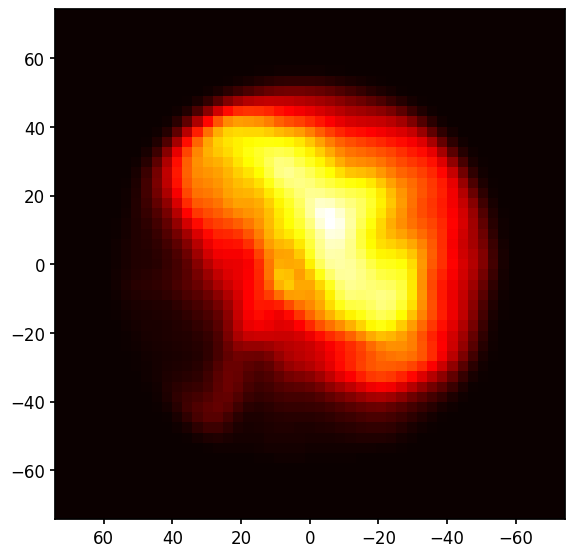

In [4]:
fig, ax = plt.subplots()
ax.pcolormesh(source.pixel_centers, source.pixel_centers, source.source)
ax.set_aspect("equal")
ax.set_xlim(source.pixel_centers[-1], source.pixel_centers[0])
ax.set_ylim(source.pixel_centers[0], source.pixel_centers[-1]);